In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

df = pd.read_csv('websites.csv')

In [2]:

# y_true = df['Is Scam Website'].isin(['Yes'])
# y_pred = df['verdict'].isin(['likely_scam', 'scam'])

# # Compute metrics
# precision = precision_score(y_true, y_pred)
# recall = recall_score(y_true, y_pred)
# f1 = f1_score(y_true, y_pred)

# print(f"Precision: {precision:.3f}")
# print(f"Recall: {recall:.3f}")
# print(f"F1 Score: {f1:.3f}")

# cross_table = pd.crosstab(df['verdict'], df['Is Scam Website'])
# cross_table = cross_table.reindex(['legitimate', 'likely_legitimate', 'uncertain', 'likely_scam', 'scam'])

# print(cross_table) # Verdict Distribution

### WITH UNCERTAIN

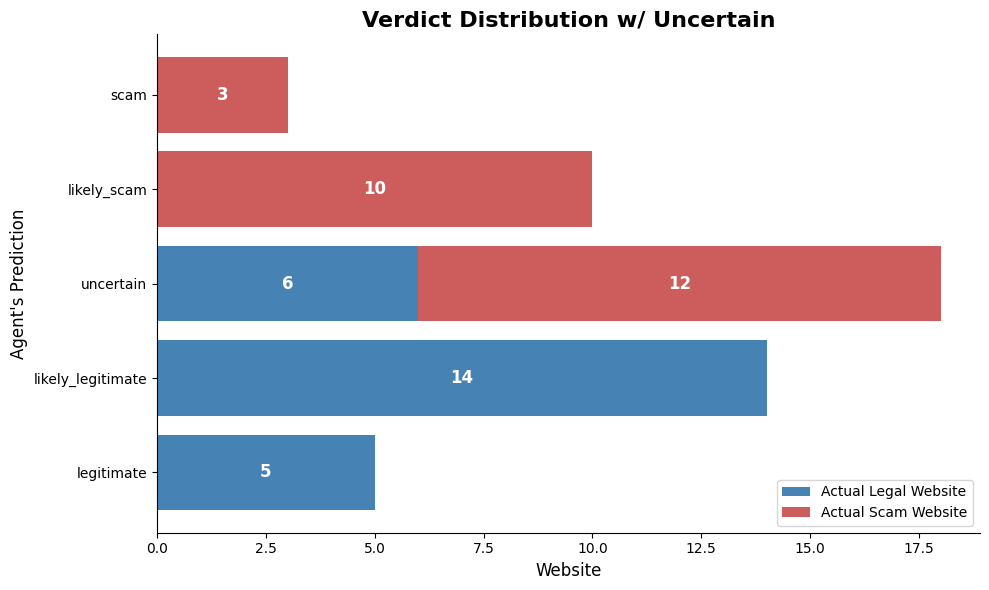

In [3]:
# Verdict Distribution Uncertain Plot
y_true = df['Is Scam Website'].isin(['Yes'])
y_pred = df['verdict'].isin(['likely_scam', 'scam'])

cross_table = pd.crosstab(df['verdict'], df['Is Scam Website'])
cross_table = cross_table.reindex(['legitimate', 'likely_legitimate', 'uncertain', 'likely_scam', 'scam'])

# Verdict Distribution Uncertain Plot
fig, ax = plt.subplots(figsize=(10, 6))

false_bar = ax.barh(cross_table.index, cross_table['No'], label='Actual Legal Website', color='steelblue')
true_bar = ax.barh(cross_table.index, cross_table['Yes'], label='Actual Scam Website', color='indianred', left=cross_table['No'])

ax.set_xlabel('Website', fontsize=12)
ax.set_ylabel('Agent\'s Prediction', fontsize=12)
ax.set_title('Verdict Distribution w/ Uncertain', fontsize=16, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)

for bar in false_bar:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w/2, bar.get_y() + bar.get_height()/2, f'{int(w)}', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=12)

for bar in true_bar:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w/2, bar.get_y() + bar.get_height()/2, f'{int(w)}', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Verdict Distribution with uncertain.png', dpi=900)
plt.show()

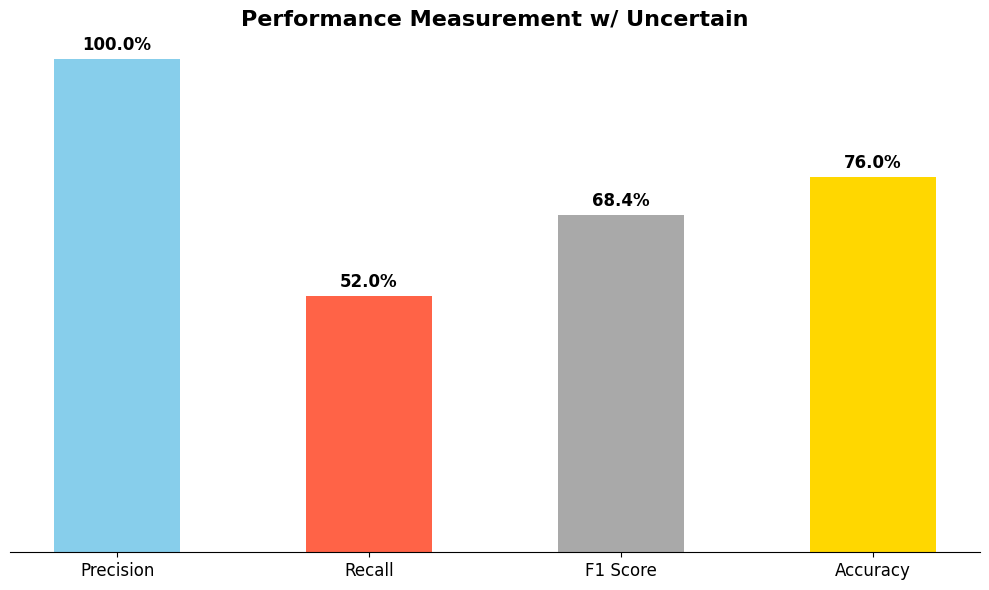

In [4]:
# Compute metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['skyblue', 'tomato', 'darkgray', 'gold']
bars = ax.bar(['Precision', "Recall", "F1 Score", "Accuracy"], [precision, recall, f1, accuracy], color=colors, width=0.5)

ax.set_title('Performance Measurement w/ Uncertain', fontsize=16, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

ax.get_yaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.savefig('Performance Measurement with uncertain.png', dpi=900)
plt.show()

### WITHOUT UNCERTAIN

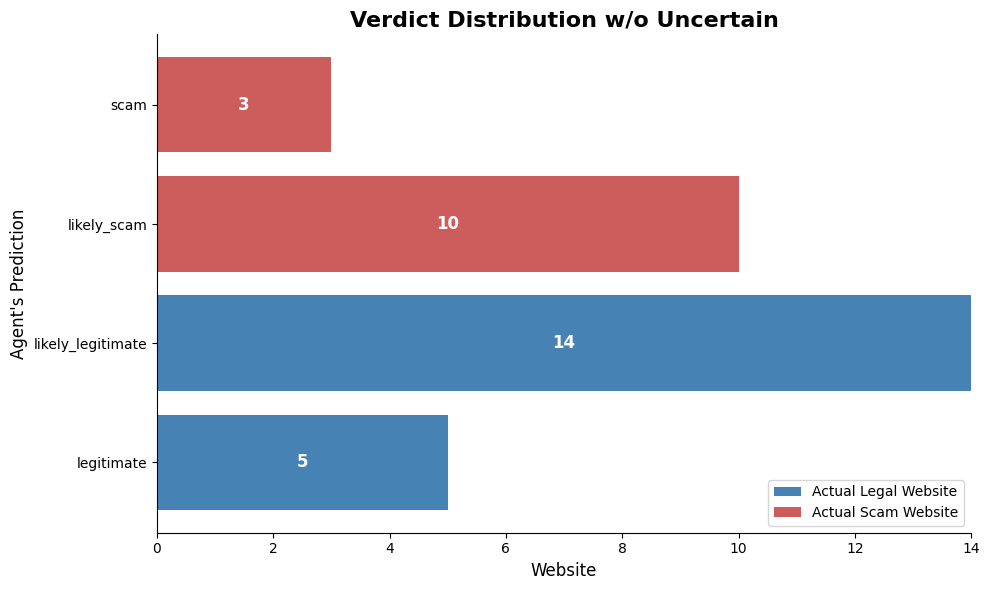

In [5]:
# Verdict Distribution Uncertain Plot
df = df[df['verdict'] != 'uncertain']

y_true = df['Is Scam Website'].isin(['Yes'])
y_pred = df['verdict'].isin(['likely_scam', 'scam'])

cross_table = pd.crosstab(df['verdict'], df['Is Scam Website'])
cross_table = cross_table.reindex(['legitimate', 'likely_legitimate', 'likely_scam', 'scam'])

# Verdict Distribution Uncertain Plot
fig, ax = plt.subplots(figsize=(10, 6))

false_bar = ax.barh(cross_table.index, cross_table['No'], label='Actual Legal Website', color='steelblue')
true_bar = ax.barh(cross_table.index, cross_table['Yes'], label='Actual Scam Website', color='indianred', left=cross_table['No'])

ax.set_xlabel('Website', fontsize=12)
ax.set_ylabel('Agent\'s Prediction', fontsize=12)
ax.set_title('Verdict Distribution w/o Uncertain', fontsize=16, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)

for bar in false_bar:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w/2, bar.get_y() + bar.get_height()/2, f'{int(w)}', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=12)

for bar in true_bar:
    w = bar.get_width()
    if w > 0:
        ax.text(bar.get_x() + w/2, bar.get_y() + bar.get_height()/2, f'{int(w)}', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('Verdict Distribution without uncertain.png', dpi=900)
plt.show()

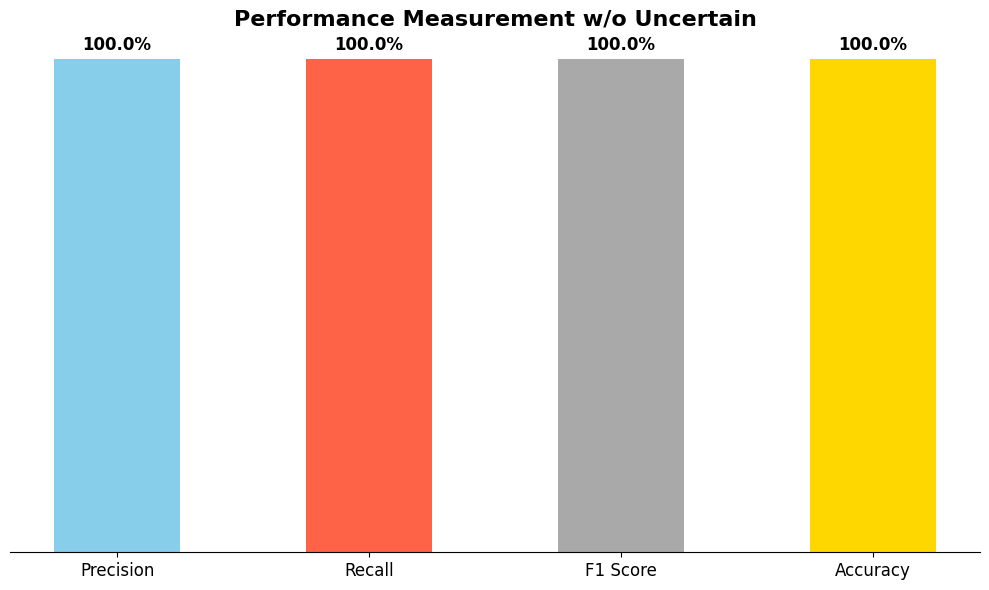

In [6]:
# Compute metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['skyblue', 'tomato', 'darkgray', 'gold']
bars = ax.bar(['Precision', "Recall", "F1 Score", "Accuracy"], [precision, recall, f1, accuracy], color=colors, width=0.5)

ax.set_title('Performance Measurement w/o Uncertain', fontsize=16, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

ax.get_yaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.savefig('Performance Measurement without uncertain.png', dpi=900)
plt.show()